In [ ]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import tensorflow as tf

warnings.filterwarnings("ignore")

# --------------------------------------------------
# Reproducibility
# --------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --------------------------------------------------
# Constants
# --------------------------------------------------

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

EPOCHS_HEAD = 10
EPOCHS_FINE = 20

AUTOTUNE = tf.data.AUTOTUNE

# --------------------------------------------------
# Dataset Paths
# --------------------------------------------------

DATASET_PATH = "/kaggle/input/datasets"

COCONUT_PATH      = os.path.join(DATASET_PATH, "jigarbaraiya")
COCONUT_PATH1     = os.path.join(DATASET_PATH, "samitha96")
BANANA_PATH       = os.path.join(DATASET_PATH, "ntambaraetienne")
MANGO_PATH        = os.path.join(DATASET_PATH, "warcoder")
RICE_PATH         = os.path.join(DATASET_PATH, "vbookshelf")
RICE_PATH1        = os.path.join(DATASET_PATH, "soni535")
BLACKPEPPER_PATH  = os.path.join(DATASET_PATH, "adithyantg")
COFFEE_PATH       = os.path.join(DATASET_PATH, "nirmalsankalana")

# --------------------------------------------------
# GPU Check
# --------------------------------------------------

print("=" * 60)

print("TensorFlow :", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU Found :", gpus[0].name)
else:
    print("Running on CPU")

print("=" * 60)

TensorFlow : 2.20.0
GPU Found : /physical_device:GPU:0


In [ ]:
# ============================================================
# BLOCK 2 : BUILD MASTER DATASET
# ============================================================

import os
import pandas as pd

records = []


# --------------------------------------------------
# Helper Function
# --------------------------------------------------

def add_dataset(root_path, crop_name=None):

    for root, _, files in os.walk(root_path):

        image_files = [
            f for f in files
            if f.lower().endswith((".jpg", ".jpeg"))
        ]

        if len(image_files) == 0:
            continue

        if crop_name is None:
            continue

        disease = os.path.basename(root)
        crop = crop_name

        for file in image_files:

            records.append(
                {
                    "image_path": os.path.join(root, file),
                    "crop": crop.strip(),
                    "disease": disease.strip(),
                    "label": f"{crop.strip()}___{disease.strip()}"
                }
            )


# --------------------------------------------------
# Add Datasets
# --------------------------------------------------

add_dataset(COCONUT_PATH, "Coconut")

add_dataset(COCONUT_PATH1, "Coconut")

add_dataset(BANANA_PATH, "Banana")

add_dataset(MANGO_PATH, "Mango")

add_dataset(RICE_PATH, "Rice")

add_dataset(RICE_PATH1, "Rice")

add_dataset(BLACKPEPPER_PATH, "BlackPepper")

add_dataset(COFFEE_PATH, "Coffee")


# --------------------------------------------------
# Create DataFrame
# --------------------------------------------------

master_df = pd.DataFrame(records)

print("=" * 60)
print("MASTER DATASET CREATED")
print("=" * 60)

print("Total Images :", len(master_df))
print("Unique Crops :", master_df["crop"].nunique())
print("Unique Labels:", master_df["label"].nunique())

master_df.head()

MASTER DATASET CREATED
Total Images : 20169
Unique Crops : 6
Unique Labels: 39


,image_path,crop,disease,label
0,/kaggle/input/datasets/jigarbaraiya/coconut-le...,Coconut,Leaf_Spot,Coconut___Leaf_Spot
1,/kaggle/input/datasets/jigarbaraiya/coconut-le...,Coconut,Leaf_Spot,Coconut___Leaf_Spot
2,/kaggle/input/datasets/jigarbaraiya/coconut-le...,Coconut,Leaf_Spot,Coconut___Leaf_Spot
3,/kaggle/input/datasets/jigarbaraiya/coconut-le...,Coconut,Leaf_Spot,Coconut___Leaf_Spot
4,/kaggle/input/datasets/jigarbaraiya/coconut-le...,Coconut,Leaf_Spot,Coconut___Leaf_Spot


In [19]:
print(master_df["crop"].value_counts())

print("\n" + "="*60)

print(master_df["label"].value_counts())

crop
Rice           7009
Coconut        5163
Mango          4000
coffee         1560
BlackPepper    1500
Banana          937
Name: count, dtype: int64

label
Rice___Leaf Blast                   1234
Rice___Sheath Blight                1096
Coconut___WCLWD_Yellowing           1084
Coconut___WCLWD_DryingofLeaflets    1078
Rice___Brown Spot                   1077
Coconut___WCLWD_Flaccidity          1069
Coconut___CCI_Caterpillars           990
Rice___Rice Hispa                    879
Coconut___CCI_Leaflets               795
coffee___healthy                     791
Rice___Leaf scald                    749
Rice___Bacterial Leaf Blight         716
Rice___Healthy Rice Leaf             668
coffee___rust                        602
BlackPepper___Slow-Decline           500
Mango___Cutting Weevil               500
BlackPepper___Pollu_Disease          500
BlackPepper___Footrot                500
Mango___Powdery Mildew               500
Mango___Sooty Mould                  500
Mango___Bacterial Cank

In [20]:
# ============================================================
# STANDARDIZE LABEL NAMES
# ============================================================

label_mapping = {
    # ---------------- Rice ----------------
    "Brown spot": "Brown Spot",
    "Bacterial leaf blight": "Bacterial Leaf Blight",
    "Leaf smut": "Leaf Smut",

    # ---------------- Coconut ----------------
    "Healthy_Leaves": "Healthy",
}

master_df["disease"] = (
    master_df["disease"]
    .replace(label_mapping)
    .str.strip()
)

master_df["label"] = (
    master_df["crop"] + "___" + master_df["disease"]
)

In [24]:
# Remove classes with fewer than 20 images
min_samples = 20

label_counts = master_df["label"].value_counts()
valid_labels = label_counts[label_counts >= min_samples].index

master_df = master_df[master_df["label"].isin(valid_labels)].reset_index(drop=True)

print("Remaining classes:", master_df["label"].nunique())
print("Remaining images:", len(master_df))
print(master_df["label"].value_counts().sort_values().head(10))

Remaining classes: 33
Remaining images: 20152
label
Rice___Leaf Smut                  40
Banana___healthy                 129
Coconut___Healthy                130
Banana___cordana                 162
coffee___red_spider_mite         167
Banana___pestalotiopsis          173
Rice___Narrow Brown Leaf Spot    470
Banana___sigatoka                473
Mango___Anthracnose              500
Mango___Powdery Mildew           500
Name: count, dtype: int64


In [26]:
# ============================================================
# BLOCK 2.5 : DATASET CLEANING
# ============================================================

from PIL import Image

# --------------------------------------------------
# Remove duplicate image paths
# --------------------------------------------------

master_df = master_df.drop_duplicates(
    subset="image_path"
).reset_index(drop=True)

# --------------------------------------------------
# Remove missing files
# --------------------------------------------------

master_df = master_df[
    master_df["image_path"].apply(os.path.exists)
].reset_index(drop=True)

# --------------------------------------------------
# Verify Images
# --------------------------------------------------

valid_images = []

for path in master_df["image_path"]:

    try:
        with Image.open(path) as img:
            img.verify()

        valid_images.append(True)

    except Exception:
        valid_images.append(False)

master_df = master_df[
    valid_images
].reset_index(drop=True)

# --------------------------------------------------
# Summary
# --------------------------------------------------

print("=" * 60)
print("DATASET CLEANING COMPLETED")
print("=" * 60)

print(f"Total Images : {len(master_df)}")
print(f"Unique Crops : {master_df['crop'].nunique()}")
print(f"Unique Labels: {master_df['label'].nunique()}")

print("\nSmallest Classes")
print(master_df["label"].value_counts().tail(10))

print("\nLargest Classes")
print(master_df["label"].value_counts().head(10))

DATASET CLEANING COMPLETED
Total Images : 20152
Unique Crops : 6
Unique Labels: 33

Smallest Classes
label
Mango___Sooty Mould              500
Mango___Gall Midge               500
Banana___sigatoka                473
Rice___Narrow Brown Leaf Spot    470
Banana___pestalotiopsis          173
coffee___red_spider_mite         167
Banana___cordana                 162
Coconut___Healthy                130
Banana___healthy                 129
Rice___Leaf Smut                  40
Name: count, dtype: int64

Largest Classes
label
Rice___Leaf Blast                   1234
Rice___Brown Spot                   1117
Rice___Sheath Blight                1096
Coconut___WCLWD_Yellowing           1084
Coconut___WCLWD_DryingofLeaflets    1078
Coconut___WCLWD_Flaccidity          1069
Coconut___CCI_Caterpillars           990
Rice___Rice Hispa                    879
Coconut___CCI_Leaflets               795
coffee___healthy                     791
Name: count, dtype: int64


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ============================================================
# Encode Labels
# ============================================================

label_encoder = LabelEncoder()
master_df["label_id"] = label_encoder.fit_transform(master_df["label"])

NUM_CLASSES = len(label_encoder.classes_)

print(f"Total Classes: {NUM_CLASSES}")

# ============================================================
# Train / Validation / Test Split
# ============================================================

train_df, temp_df = train_test_split(
    master_df,
    test_size=0.30,
    stratify=master_df["label_id"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_id"],
    random_state=42
)

print("\nDataset Split")
print("-" * 30)
print(f"Train : {len(train_df)}")
print(f"Validation : {len(val_df)}")
print(f"Test : {len(test_df)}")

print("\nClass Distribution")
print(train_df["label"].value_counts().head())

Total Classes: 33

Dataset Split
------------------------------
Train : 14106
Validation : 3023
Test : 3023

Class Distribution
label
Rice___Leaf Blast                   864
Rice___Brown Spot                   782
Rice___Sheath Blight                767
Coconut___WCLWD_Yellowing           759
Coconut___WCLWD_DryingofLeaflets    755
Name: count, dtype: int64


In [5]:
print(len(train_df))
print(len(val_df))
print(len(test_df))

36108
5158
10318


In [28]:
# ============================================================
# BLOCK 4 : CONFIGURATION
# ============================================================

import tensorflow as tf
import numpy as np

# -----------------------------
# Image Configuration
# -----------------------------
IMAGE_SIZE = (300, 300)
BATCH_SIZE = 16

# -----------------------------
# Performance
# -----------------------------
AUTOTUNE = tf.data.AUTOTUNE

# -----------------------------
# Classes
# -----------------------------
CLASS_NAMES = list(label_encoder.classes_)
NUM_CLASSES = len(CLASS_NAMES)

print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
print(f"TensorFlow Version : {tf.__version__}")
print(f"Image Size         : {IMAGE_SIZE}")
print(f"Batch Size         : {BATCH_SIZE}")
print(f"Number of Classes  : {NUM_CLASSES}")

print("\nFirst 10 Classes:")
for i, cls in enumerate(CLASS_NAMES[:10]):
    print(f"{i:2d} : {cls}")

CONFIGURATION
TensorFlow Version : 2.20.0
Image Size         : (300, 300)
Batch Size         : 16
Number of Classes  : 33

First 10 Classes:
 0 : Banana___cordana
 1 : Banana___healthy
 2 : Banana___pestalotiopsis
 3 : Banana___sigatoka
 4 : BlackPepper___Footrot
 5 : BlackPepper___Pollu_Disease
 6 : BlackPepper___Slow-Decline
 7 : Coconut___CCI_Caterpillars
 8 : Coconut___CCI_Leaflets
 9 : Coconut___Healthy


In [31]:
# ============================================================
# BLOCK 5 : TF.DATA PIPELINE
# ============================================================

from tensorflow.keras.applications.efficientnet import preprocess_input

# ------------------------------------------------------------
# Read Image
# ------------------------------------------------------------
def load_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(image, tf.float32)

    image = preprocess_input(image)

    return image, label


# ------------------------------------------------------------
# Create Dataset
# ------------------------------------------------------------
def create_dataset(df, training=False):

    paths = df["image_path"].astype(str).values
    labels = df["label_id"].astype(np.int32).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(
            buffer_size=len(df),
            seed=42,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE)

    ds = ds.prefetch(AUTOTUNE)

    return ds


# ------------------------------------------------------------
# Create Datasets
# ------------------------------------------------------------
train_ds = create_dataset(train_df, training=True)

val_ds = create_dataset(val_df)

test_ds = create_dataset(test_df)

print("=" * 60)
print("DATASETS CREATED")
print("=" * 60)

print("Training Batches   :", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation Batches :", tf.data.experimental.cardinality(val_ds).numpy())
print("Testing Batches    :", tf.data.experimental.cardinality(test_ds).numpy())

I0000 00:00:1784881692.490878      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784881692.493700      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


DATASETS CREATED
Training Batches   : 882
Validation Batches : 189
Testing Batches    : 189


In [33]:
# ============================================================
# BLOCK 6 : DATA AUGMENTATION + MODEL
# ============================================================

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.regularizers import l2

# ------------------------------------------------------------
# Data Augmentation
# ------------------------------------------------------------
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.10),

    layers.RandomZoom(0.15),

    layers.RandomContrast(0.15),

    layers.RandomTranslation(
        height_factor=0.08,
        width_factor=0.08
    ),

], name="augmentation")


# ------------------------------------------------------------
# EfficientNetB3 Backbone
# ------------------------------------------------------------
backbone = EfficientNetB3(

    include_top=False,

    weights="imagenet",

    input_shape=(300, 300, 3)

)

backbone.trainable = False


# ------------------------------------------------------------
# Build Model
# ------------------------------------------------------------
inputs = layers.Input(shape=(300, 300, 3))

x = data_augmentation(inputs)

x = backbone(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.40)(x)

x = layers.Dense(
    512,
    activation="swish",
    kernel_regularizer=l2(1e-4)
)(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.30)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 33)             │        16,929 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,595,600 (44.23 MB)

 Trainable params: 807,969 (3.08 MB)

 Non-trainable params: 10,787,631 (41.15 MB)

In [ ]:
# ============================================================
# BLOCK 7 : COMPILE MODEL
# ============================================================

from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# ------------------------------------------------------------
# Learning Rate Schedule
# ------------------------------------------------------------

INITIAL_LR = 3e-4

lr_schedule = CosineDecay(
    initial_learning_rate=INITIAL_LR,
    decay_steps=len(train_ds) * 20,      
    alpha=1e-2                           
)

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-4,
    clipnorm=1.0
)

# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

loss_fn = SparseCategoricalCrossentropy()

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

model.compile(

    optimizer=optimizer,

    loss=SparseCategoricalCrossentropy(),

    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=3,
            name="top3_accuracy"
        )
    ]

)

print("=" * 60)
print("MODEL COMPILED SUCCESSFULLY")
print("=" * 60)
print("Learning Rate :", INITIAL_LR)
print("Weight Decay  :", 1e-4)
print("Label Smoothing :", 0.1)

MODEL COMPILED SUCCESSFULLY
Learning Rate : 0.0003
Weight Decay  : 0.0001
Label Smoothing : 0.1


In [36]:
# ============================================================
# BLOCK 8 : CALLBACKS
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    CSVLogger,
    TerminateOnNaN
)

# ------------------------------------------------------------
# Early Stopping
# ------------------------------------------------------------

early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=8,

    restore_best_weights=True,

    verbose=1

)

# ------------------------------------------------------------
# Save Best Model
# ------------------------------------------------------------

checkpoint = ModelCheckpoint(

    "best_efficientnet_b3.keras",

    monitor="val_accuracy",

    save_best_only=True,

    mode="max",

    verbose=1

)

# ------------------------------------------------------------
# Training Log
# ------------------------------------------------------------

csv_logger = CSVLogger(

    "training_log.csv",

    append=False

)

# ------------------------------------------------------------
# Stop if Loss becomes NaN
# ------------------------------------------------------------

terminate_nan = TerminateOnNaN()

# ------------------------------------------------------------
# Callback List
# ------------------------------------------------------------

callbacks = [

    early_stopping,

    checkpoint,

    csv_logger,

    terminate_nan

]

print("=" * 60)
print("CALLBACKS READY")
print("=" * 60)

CALLBACKS READY


In [37]:
# ============================================================
# BLOCK 9 : STAGE 1 TRAINING
# ============================================================

EPOCHS_STAGE1 = 15

print("=" * 60)
print("STAGE 1 TRAINING")
print("=" * 60)
print("Backbone Frozen :", not backbone.trainable)

history_stage1 = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS_STAGE1,

    callbacks=callbacks,

    verbose=1

)

STAGE 1 TRAINING
Backbone Frozen : True
Epoch 1/15


E0000 00:00:1784881994.273952      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


882/882 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.5516 - loss: 1.6862 - top3_accuracy: 0.7681
Epoch 1: val_accuracy improved from None to 0.84849, saving model to best_efficientnet_b3.keras

Epoch 1: finished saving model to best_efficientnet_b3.keras
882/882 ━━━━━━━━━━━━━━━━━━━━ 176s 176ms/step - accuracy: 0.6721 - loss: 1.1439 - top3_accuracy: 0.8803 - val_accuracy: 0.8485 - val_loss: 0.5172 - val_top3_accuracy: 0.9785
Epoch 2/15
882/882 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.7920 - loss: 0.6972 - top3_accuracy: 0.9578
Epoch 2: val_accuracy improved from 0.84849 to 0.86834, saving model to best_efficientnet_b3.keras

Epoch 2: finished saving model to best_efficientnet_b3.keras
882/882 ━━━━━━━━━━━━━━━━━━━━ 149s 168ms/step - accuracy: 0.7972 - loss: 0.6868 - top3_accuracy: 0.9589 - val_accuracy: 0.8683 - val_loss: 0.4638 - val_top3_accuracy: 0.9815
Epoch 3/15
882/882 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8197 - loss: 0.6161 - top3_accuracy: 0.9639
Epoch 3: v

In [38]:
# ============================================================
# BLOCK 10 : FINE-TUNING
# ============================================================

# Unfreeze the backbone
backbone.trainable = True

# Freeze the lower layers
for layer in backbone.layers[:-40]:
    layer.trainable = False

print("Trainable layers:",
      sum(layer.trainable for layer in backbone.layers))

from tensorflow.keras.optimizers import AdamW

model.compile(

    optimizer=AdamW(
        learning_rate=1e-5,
        weight_decay=1e-5,
        clipnorm=1.0
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=3,
            name="top3_accuracy"
        )
    ]
)

EPOCHS_STAGE2 = 15

history_stage2 = model.fit(

    train_ds,

    validation_data=val_ds,

    initial_epoch=len(history_stage1.history["loss"]),

    epochs=len(history_stage1.history["loss"]) + EPOCHS_STAGE2,

    callbacks=callbacks,

    verbose=1
)

Trainable layers: 40
Epoch 16/30


E0000 00:00:1784884815.873475      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


882/882 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.8218 - loss: 0.6263 - top3_accuracy: 0.9634
Epoch 16: val_accuracy did not improve from 0.92987
882/882 ━━━━━━━━━━━━━━━━━━━━ 199s 201ms/step - accuracy: 0.8377 - loss: 0.5720 - top3_accuracy: 0.9706 - val_accuracy: 0.9193 - val_loss: 0.3323 - val_top3_accuracy: 0.9901
Epoch 17/30
882/882 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.8723 - loss: 0.4715 - top3_accuracy: 0.9807
Epoch 17: val_accuracy improved from 0.92987 to 0.93152, saving model to best_efficientnet_b3.keras

Epoch 17: finished saving model to best_efficientnet_b3.keras
882/882 ━━━━━━━━━━━━━━━━━━━━ 175s 199ms/step - accuracy: 0.8732 - loss: 0.4617 - top3_accuracy: 0.9816 - val_accuracy: 0.9315 - val_loss: 0.3008 - val_top3_accuracy: 0.9940
Epoch 18/30
882/882 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.8794 - loss: 0.4448 - top3_accuracy: 0.9834
Epoch 18: val_accuracy improved from 0.93152 to 0.93814, saving model to best_efficientnet_b3.keras

Epoch 18: f

In [39]:
# ============================================================
# BLOCK 11 : MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import numpy as np

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("="*60)
print("FINAL TEST RESULTS")
print("="*60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\nClassification Report\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4
))

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\nConfusion Matrix Shape:", cm.shape)

FINAL TEST RESULTS
Accuracy : 0.9676
Precision: 0.9673
Recall   : 0.9676
F1 Score : 0.9671

Classification Report

                                  precision    recall  f1-score   support

                Banana___cordana     0.9200    0.9583    0.9388        24
                Banana___healthy     0.9524    1.0000    0.9756        20
         Banana___pestalotiopsis     1.0000    0.9231    0.9600        26
               Banana___sigatoka     0.9857    0.9718    0.9787        71
           BlackPepper___Footrot     1.0000    0.9867    0.9933        75
     BlackPepper___Pollu_Disease     0.9868    1.0000    0.9934        75
      BlackPepper___Slow-Decline     1.0000    1.0000    1.0000        75
      Coconut___CCI_Caterpillars     1.0000    1.0000    1.0000       148
          Coconut___CCI_Leaflets     0.9917    1.0000    0.9958       119
               Coconut___Healthy     1.0000    0.9500    0.9744        20
Coconut___WCLWD_DryingofLeaflets     1.0000    0.9938    0.9969       

In [43]:
# ============================================================
# BLOCK 14 : SINGLE IMAGE PREDICTION
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# ------------------------------------------------------------
# Load Trained Model
# ------------------------------------------------------------

model = tf.keras.models.load_model("best_efficientnet_b3.keras")

# ------------------------------------------------------------
# Prediction Function
# ------------------------------------------------------------

def predict_image(img_path):

    img = image.load_img(
        img_path,
        target_size=IMAGE_SIZE
    )

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

    predictions = model.predict(img_array, verbose=0)[0]

    predicted_index = np.argmax(predictions)

    confidence = predictions[predicted_index]

    predicted_label = CLASS_NAMES[predicted_index]

    crop, disease = predicted_label.split("___")

    print("=" * 60)
    print("Prediction")
    print("=" * 60)
    print(f"Crop       : {crop}")
    print(f"Disease    : {disease}")
    print(f"Confidence : {confidence*100:.2f}%")

    print("\nTop 5 Predictions")
    print("-" * 60)

    top5 = np.argsort(predictions)[::-1][:5]

    for idx in top5:
        print(
            f"{CLASS_NAMES[idx]:40s}"
            f"{predictions[idx]*100:.2f}%"
        )

    return predictions



In [44]:
print(test_df.iloc[0]["image_path"])

/kaggle/input/datasets/adithyantg/black-pepper-leaf-disease-mini-dataset/BLACK_PEPPER_DATASET/Pollu_Disease/IMG_20250311_164113.jpeg


In [45]:
predict_image(test_df.iloc[0]["image_path"])

Prediction
Crop       : BlackPepper
Disease    : Pollu_Disease
Confidence : 99.95%

Top 5 Predictions
------------------------------------------------------------
BlackPepper___Pollu_Disease             99.95%
BlackPepper___Footrot                   0.03%
Coconut___WCLWD_Yellowing               0.00%
Mango___Bacterial Canker                0.00%
Mango___Powdery Mildew                  0.00%


array([4.0738257e-09, 2.3425670e-07, 1.1803745e-06, 2.0962541e-07,
       2.6067326e-04, 9.9952745e-01, 4.0252953e-06, 7.1022161e-09,
       2.0837720e-06, 3.7103771e-06, 1.9323195e-06, 3.8053204e-06,
       4.7959766e-05, 6.9289030e-08, 4.2151016e-05, 7.9569006e-08,
       9.2144411e-08, 6.1330240e-07, 6.6288159e-08, 3.7508202e-05,
       2.7042124e-05, 2.2384080e-05, 6.2453708e-08, 8.1640401e-08,
       2.4330569e-07, 3.3905148e-06, 3.7326029e-07, 2.1895319e-06,
       8.5305192e-06, 1.2714539e-06, 1.8735622e-09, 2.2814552e-07,
       3.9743284e-07], dtype=float32)

In [ ]:
# ============================================================
# BLOCK 16 : GRAD-CAM FUNCTIONS
# ============================================================

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Find Last Convolution Layer Automatically
# ------------------------------------------------------------

def get_last_conv_layer(model):

    for layer in reversed(model.layers):

        try:
            if len(layer.output.shape) == 4:
                return layer.name
        except:
            continue

    raise ValueError("No Conv Layer Found")


LAST_CONV_LAYER = "top_conv"

print("Last Conv Layer :", LAST_CONV_LAYER)


# ------------------------------------------------------------
# Grad-CAM Heatmap
# ------------------------------------------------------------

def make_gradcam_heatmap(img_array, model, backbone, last_conv_layer_name):

    last_conv_layer = backbone.get_layer(last_conv_layer_name)

    grad_model = tf.keras.models.Model(
        inputs=backbone.input,
        outputs=[
            last_conv_layer.output,
            backbone.output
        ]
    )

    classifier = tf.keras.Sequential(model.layers[3:])

    with tf.GradientTape() as tape:

        conv_output, features = grad_model(img_array)

        tape.watch(conv_output)

        predictions = classifier(features)

        class_idx = tf.argmax(predictions[0])

        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]

    heatmap = tf.reduce_sum(conv_output * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)

    heatmap /= tf.reduce_max(heatmap) + 1e-10

    return heatmap.numpy()

Last Conv Layer : top_conv


In [58]:
# ============================================================
# BLOCK 17 : DISPLAY GRAD-CAM
# ============================================================

def display_gradcam(img_path):

    # -------------------------
    # Load image
    # -------------------------
    img = image.load_img(
        img_path,
        target_size=IMAGE_SIZE
    )

    img_array = image.img_to_array(img)

    input_array = np.expand_dims(img_array.copy(), axis=0)

    input_array = tf.keras.applications.efficientnet.preprocess_input(
        input_array
    )

    # -------------------------
    # Generate Heatmap
    # -------------------------
    heatmap = make_gradcam_heatmap(
        input_array,
        model,
        backbone,
        LAST_CONV_LAYER
    )

    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.resize(
        heatmap,
        IMAGE_SIZE
    )

    heatmap_color = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    original = img_array.astype("uint8")

    overlay = cv2.addWeighted(
        original,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    # -------------------------
    # Prediction
    # -------------------------
    prediction = model.predict(
        input_array,
        verbose=0
    )[0]

    idx = np.argmax(prediction)

    confidence = prediction[idx]

    # -------------------------
    # Plot
    # -------------------------
    plt.figure(figsize=(18,6))

    plt.subplot(1,3,1)
    plt.imshow(original.astype("uint8"))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(
        f"{CLASS_NAMES[idx]}\n"
        f"{confidence*100:.2f}%"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

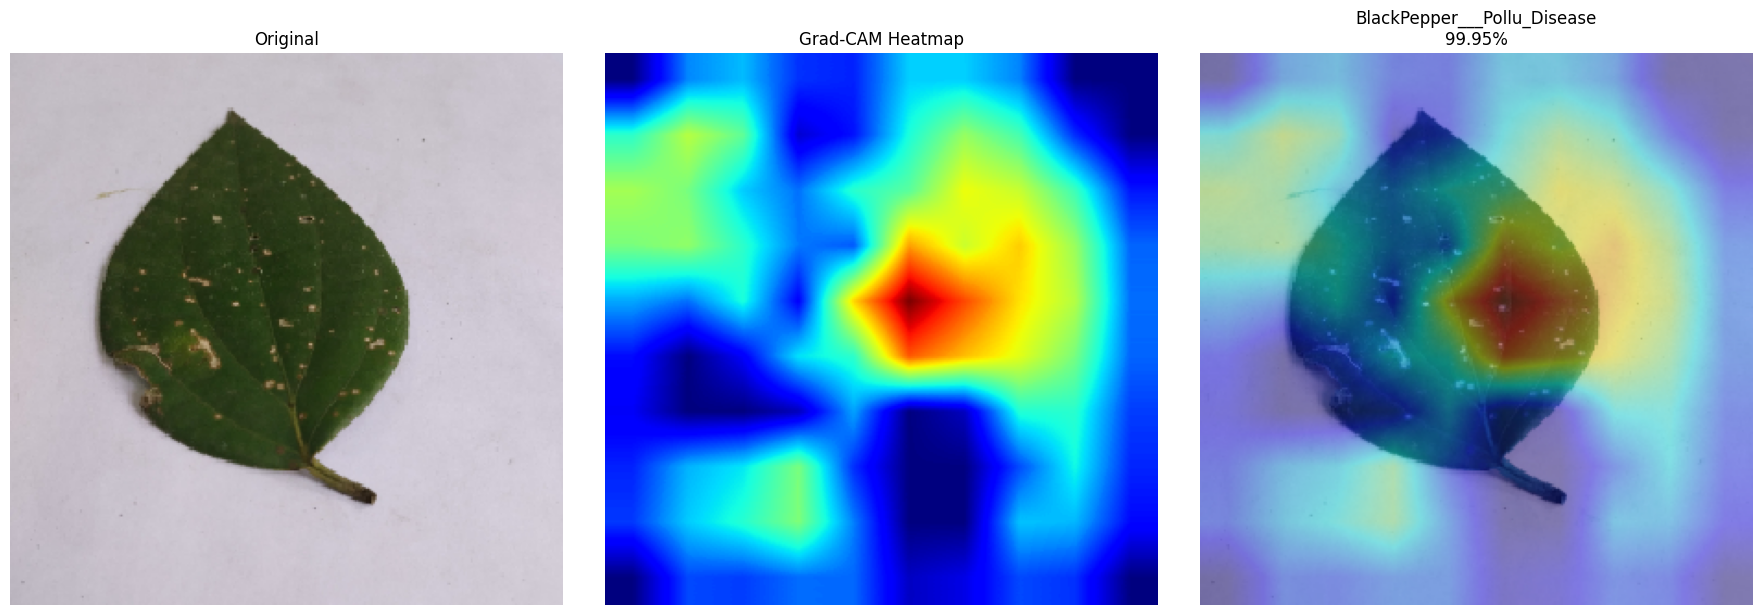

In [59]:
display_gradcam(test_df.iloc[0]["image_path"])